# 06. Random Forest Model and High-Risk Threshold Tuning

This notebook develops a stronger tree-based model.
The workflow uses a tested `scikit-learn` Random Forest, chronological validation, validation-only threshold tuning and a final untouched test-period evaluation.

**Primary inputs:** the ML-ready feature matrices and identifier files created by `04_feature_engineering_portfolio.ipynb`.

**Comparison input:** `baseline_model_results.csv` created by `05_ml_baseline_portfolio.ipynb`.


## Notebook roadmap

1. Setup
2. Load train, validation, test, scoring and identifier tables
3. Validate feature alignment, chronology, missing values and leakage safeguards
4. Review class imbalance and calculate class weights
5. Define a Random Forest candidate set
6. Fit every candidate on the complete training period
7. Select one candidate using validation metrics
8. Tune the high-risk probability threshold on validation data
9. Evaluate the frozen model and threshold on the untouched test period
10. Compare the Random Forest with the earlier baselines
11. Inspect impurity importance, validation permutation importance and tree complexity
12. Refit the selected configuration on all labeled history and score the latest month
13. Export backward-compatible files, predictions, models, documentation and quality checks


## 1. Setup

In [1]:
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_fscore_support,
    roc_auc_score)
from sklearn.preprocessing import label_binarize

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
TARGET_COL = "next_month_risk_label"
RISK_LABELS = [0, 1, 2]
LABEL_NAMES = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}
MINIMUM_HIGH_RISK_RECALL = 0.70

INPUT_DIR = Path("../data/full_data/feature_engineering")
BASELINE_DIR = Path("../data/full_data/ml_baseline")
OUTPUT_DIR = Path("../data/full_data/ml_stronger")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Feature input folder: {INPUT_DIR}")
print(f"Baseline folder:      {BASELINE_DIR}")
print(f"Output folder:        {OUTPUT_DIR}")
print(f"Random seed:          {RANDOM_SEED}")


Feature input folder: ..\data\full_data\feature_engineering
Baseline folder:      ..\data\full_data\ml_baseline
Output folder:        ..\data\full_data\ml_stronger
Random seed:          42


## 2. Load the modeling datasets


In [2]:
# Load required labeled matrices plus optional scoring and identifier files
def load_modeling_inputs(input_dir=INPUT_DIR):
    required = {
        "train": input_dir / "train_feature_engineered_ml_ready.csv",
        "valid": input_dir / "valid_feature_engineered_ml_ready.csv",
        "test": input_dir / "test_feature_engineered_ml_ready.csv"}
    missing = [str(path) for path in required.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Missing required ML-ready files:\n- " + "\n- ".join(missing))

    matrices = {split: pd.read_csv(path) for split, path in required.items()}

    scoring_path = input_dir / "scoring_feature_engineered_ml_ready.csv"
    matrices["scoring"] = pd.read_csv(scoring_path) if scoring_path.exists() else None

    identifiers = {}
    for split in ["train", "valid", "test", "scoring"]:
        path = input_dir / f"{split}_feature_engineered_ids.csv"
        identifiers[split] = pd.read_csv(path) if path.exists() else None

    return matrices, identifiers


In [3]:
matrices, identifier_tables = load_modeling_inputs()

input_summary = pd.DataFrame(
    [
        {
            "split": split,
            "rows": 0 if frame is None else len(frame),
            "columns": 0 if frame is None else frame.shape[1],
            "target_available": frame is not None and TARGET_COL in frame.columns,
            "identifier_file_available": identifier_tables.get(split) is not None}
        for split, frame in matrices.items()])
display(input_summary)


,split,rows,columns,target_available,identifier_file_available
0,train,63280,229,True,True
1,valid,16000,229,True,True
2,test,20000,229,True,True
3,scoring,2000,228,False,True


In [4]:
display(matrices["train"].head(3))
print(f"Training table shape: {matrices['train'].shape}")
print(f"Target column is last: {matrices['train'].columns[-1] == TARGET_COL}")

,units_sold,revenue,unique_customers,avg_discount_pct,units_lag_1m,units_lag_3m,revenue_lag_1m,rolling_units_mean_3m,rolling_units_mean_6m,rolling_units_std_3m,volatility_3m,mom_units_growth_pct,customer_count_growth_pct,trend_slope_3m,trend_slope_6m,stockout_flag,backorder_units,market_demand_index,competitor_pressure_index,campaign_flag,website_visits,demo_requests,risk_factor_sales_drop,risk_factor_customer_drop,risk_factor_volatility,risk_factor_under_trend,is_declining_product,is_new_product,base_list_price_eur,base_unit_cost_eur,target_margin_pct,product_growth_factor,fx_to_eur,market_growth_factor,margin_factor,order_count,active_sales_reps,avg_asp_eur,gross_profit_eur,cogs_eur,discount_value_eur,outlier_order_count,gross_margin_pct,avg_customer_size_score,avg_base_churn_probability,enterprise_customer_count,high_churn_customer_count,covered_annual_quota_eur,no_sales_flag,opening_stock_units,production_units,ending_stock_units,zero_stock_flag,inventory_value_eur,supply_coverage_ratio,standard_unit_cost_eur,actual_unit_cost_eur,cost_variance_eur,cost_variance_pct,return_units,...,churn_risk_customer_share_lag_1m,gross_profit_growth_pct,weighted_pipeline_growth_pct,return_rate_change_pct,demand_supply_gap,demand_supply_mismatch_flag,engagement_to_pipeline_ratio,pipeline_value_per_customer,marketing_efficiency_score,commercial_pressure_score,revenue_at_risk_proxy,product_line__Accessories,product_line__IT,product_line__Medical,product_line__Services,product_line____UNSEEN__,product_category__Accessory Kit,product_category__Connectivity Module,product_category__Industrial Scanner,product_category__Laptop Pro,product_category__Laptop Standard,product_category__Legacy Workstation,product_category__Medical Sensor,product_category__Monitoring Device,product_category__Service Contract,product_category__Tablet Enterprise,product_category____UNSEEN__,region__Eastern EU,region__Northern EU,region__Southern EU,region__Western EU,region____UNSEEN__,lifecycle_stage__Decline,lifecycle_stage__Growth,lifecycle_stage__Mature,lifecycle_stage__New,lifecycle_stage____UNSEEN__,dominant_margin_category__High Margin,dominant_margin_category__Low Margin,dominant_margin_category__Medium Margin,dominant_margin_category____UNSEEN__,dominant_order_size_category__Large Order,dominant_order_size_category__Medium Order,dominant_order_size_category__Small Order,dominant_order_size_category____UNSEEN__,dominant_rep_seniority__Junior,dominant_rep_seniority__Key Account,dominant_rep_seniority__Professional,dominant_rep_seniority__Senior,dominant_rep_seniority__Unknown,dominant_rep_seniority____UNSEEN__,campaign_channel__Content,campaign_channel__Email,campaign_channel__No Active Campaign,campaign_channel__Paid Search,campaign_channel__Partner,campaign_channel__Trade Fair,campaign_channel__Webinar,campaign_channel____UNSEEN__,next_month_risk_label
0,2.3736,4.2201,1.7840,0.7843,-0.4805,-0.5024,-0.3930,-0.2896,-0.2681,-0.2029,0.0511,-0.1601,-0.2092,-0.0294,-0.0708,-0.0367,-0.0143,-0.0777,0.0187,-0.4768,-0.3702,-0.4177,-0.1096,-0.6106,-0.5676,-0.7853,-0.6780,-0.1160,1.1923,1.0819,-0.3427,0.0623,0.2479,0.2190,0.7143,2.5783,3.0439,1.9507,4.8768,3.7405,4.4371,-0.1042,0.4297,-0.0018,-0.0340,-0.4949,-0.3201,3.0024,-0.9686,1.7742,3.0271,2.4223,-0.0367,-0.0434,0.4660,1.1478,1.1358,0.1425,-0.0874,-0.0951,...,-0.2894,-0.0043,-0.0932,-0.0108,-0.0783,0.0000,-0.3210,0.0083,-0.0537,-0.8008,0.7507,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,-0.2196,0.1997,0.9334,-1.8334,2.4564,-0.5024,4.3615,-0.2896,-0.2681,-0.2029,0.0511,-0.2088,0.0384,-0.0294,-0.0708,-0.0367,-0.0143,-0.0777,0.0187,-0.4768,-0.2984,-0.3007,-0.1096,1.6376,-0.5676,-0.7853,-0.6780,-0.1160,1.1923,1.0819,-0.3427,0.0623,0.2479,0.2190,0.7143,0.9073,1.1201,2.3640,0.6799,0.0514,-0.2107,-0.1042,1.3475,-0.8648,1.7821,-0.4949,2.6076,0.5576,-0.9686,-0.6894,-0.6094,-0.6290,-0.0367,-0.2931,-0.1434,1.1256,1.2107,1.7206,1.0107,-0.0951,...,-0.2894,-0.0045,0.0008,-0.0108

Training table shape: (63280, 229)
Target column is last: True


## 3. Validate feature and time-split 


In [5]:
def split_features_and_target(frame):
    if TARGET_COL not in frame.columns:
        raise KeyError(f"Missing target column: {TARGET_COL}")
    return frame.drop(columns=TARGET_COL).copy(), frame[TARGET_COL].astype(int).copy()


X_train, y_train = split_features_and_target(matrices["train"])
X_valid, y_valid = split_features_and_target(matrices["valid"])
X_test, y_test = split_features_and_target(matrices["test"])
X_scoring = None if matrices["scoring"] is None else matrices["scoring"].copy()

split_shapes = pd.DataFrame(
    {
        "split": ["train", "validation", "test", "scoring"],
        "rows": [len(X_train), len(X_valid), len(X_test), 0 if X_scoring is None else len(X_scoring)],
        "features": [X_train.shape[1], X_valid.shape[1], X_test.shape[1], 0 if X_scoring is None else X_scoring.shape[1]]})
display(split_shapes)


,split,rows,features
0,train,63280,228
1,validation,16000,228
2,test,20000,228
3,scoring,2000,228


In [6]:
def feature_quality_row(split, X, y=None):
    values = X.to_numpy(dtype=float)
    return {
        "split": split,
        "rows": len(X),
        "features": X.shape[1],
        "duplicate_columns": int(X.columns.duplicated().sum()),
        "missing_feature_values": int(X.isna().sum().sum()),
        "infinite_feature_values": int(np.isinf(values).sum()),
        "missing_target_values": 0 if y is None else int(y.isna().sum()),
        "memory_mb": float(X.memory_usage(deep=True).sum() / 1024**2)}


feature_quality = pd.DataFrame(
    [
        feature_quality_row("train", X_train, y_train),
        feature_quality_row("validation", X_valid, y_valid),
        feature_quality_row("test", X_test, y_test),
        *([feature_quality_row("scoring", X_scoring)] if X_scoring is not None else [])])
display(feature_quality)

feature_alignment = {
    "validation_matches_train": X_valid.columns.tolist() == X_train.columns.tolist(),
    "test_matches_train": X_test.columns.tolist() == X_train.columns.tolist(),
    "scoring_matches_train": X_scoring is None or X_scoring.columns.tolist() == X_train.columns.tolist()}
print("Feature alignment:", feature_alignment)

assert all(feature_alignment.values())
assert feature_quality["duplicate_columns"].eq(0).all()
assert feature_quality["missing_feature_values"].eq(0).all()
assert feature_quality["infinite_feature_values"].eq(0).all()
assert TARGET_COL not in X_train.columns
assert not any(column.endswith("_id") for column in X_train.columns)
assert set(pd.concat([y_train, y_valid, y_test]).unique()).issubset(RISK_LABELS)
print("Feature matrices are aligned and model-ready.")


,split,rows,features,duplicate_columns,missing_feature_values,infinite_feature_values,missing_target_values,memory_mb
0,train,63280,228,0,0,0,0,110.0758
1,validation,16000,228,0,0,0,0,27.8322
2,test,20000,228,0,0,0,0,34.7902
3,scoring,2000,228,0,0,0,0,3.4791


Feature alignment: {'validation_matches_train': True, 'test_matches_train': True, 'scoring_matches_train': True}
Feature matrices are aligned and model-ready.


In [7]:
chronology_rows = []
for split, target in [("train", y_train), ("valid", y_valid), ("test", y_test)]:
    identifiers = identifier_tables[split]
    if identifiers is None:
        continue
    assert len(identifiers) == len(target)
    assert identifiers[TARGET_COL].astype(int).reset_index(drop=True).equals(
        target.reset_index(drop=True))
    target_months = pd.PeriodIndex(identifiers["target_month"], freq="M")
    chronology_rows.append(
        {
            "split": split,
            "first_target_month": str(target_months.min()),
            "last_target_month": str(target_months.max()),
            "rows": len(identifiers)})

chronology_summary = pd.DataFrame(chronology_rows)
if not chronology_summary.empty:
    display(chronology_summary)
    train_end = pd.Period(chronology_summary.loc[chronology_summary["split"] == "train", "last_target_month"].iloc[0], freq="M")
    valid_start = pd.Period(chronology_summary.loc[chronology_summary["split"] == "valid", "first_target_month"].iloc[0], freq="M")
    valid_end = pd.Period(chronology_summary.loc[chronology_summary["split"] == "valid", "last_target_month"].iloc[0], freq="M")
    test_start = pd.Period(chronology_summary.loc[chronology_summary["split"] == "test", "first_target_month"].iloc[0], freq="M")
    assert train_end < valid_start <= valid_end < test_start
    print("Chronological order is valid: train → validation → test.")
else:
    print("Identifier files were not found, so month ranges cannot be displayed.")


,split,first_target_month,last_target_month,rows
0,train,2021-02,2024-06,63280
1,valid,2024-07,2025-02,16000
2,test,2025-03,2025-12,20000


Chronological order is valid: train → validation → test.


## 4. Review class imbalance and weighting


In [8]:
def target_distribution(y, split_name):
    counts = pd.Series(y).value_counts().reindex(RISK_LABELS, fill_value=0)
    result = pd.DataFrame(
        {
            "split": split_name,
            "label": RISK_LABELS,
            "label_name": [LABEL_NAMES[label] for label in RISK_LABELS],
            "rows": counts.to_numpy(dtype=int),
            "share": counts.to_numpy(dtype=float) / len(y)})
    result["share_pct"] = result["share"] * 100
    return result


target_distribution_all = pd.concat(
    [
        target_distribution(y_train, "train"),
        target_distribution(y_valid, "validation"),
        target_distribution(y_test, "test")],
    ignore_index=True)
display(target_distribution_all)


,split,label,label_name,rows,share,share_pct
0,train,0,Low Risk,43836,0.6927,69.2731
1,train,1,Medium Risk,15850,0.2505,25.0474
2,train,2,High Risk,3594,0.0568,5.6795
3,validation,0,Low Risk,10865,0.6791,67.9062
4,validation,1,Medium Risk,4676,0.2923,29.2250
5,validation,2,High Risk,459,0.0287,2.8687
6,test,0,Low Risk,13808,0.6904,69.0400
7,test,1,Medium Risk,5621,0.2811,28.1050
8,test,2,High Risk,571,0.0285,2.8550


In [11]:
train_counts = y_train.value_counts().reindex(RISK_LABELS, fill_value=0)
balanced_weights = {
    int(label): float(len(y_train) / (len(RISK_LABELS) * count))
    for label, count in train_counts.items()}
relative_balanced_weights = {
    label: weight / balanced_weights[0]
    for label, weight in balanced_weights.items()}
moderate_cost_weights = {0: 1.0, 1: 50.0, 2: 300.0}
strong_cost_weights = {0: 1.0, 1: 90.0, 2: 500.0}

weight_comparison = pd.DataFrame(
    {
        "label": RISK_LABELS,
        "label_name": [LABEL_NAMES[label] for label in RISK_LABELS],
        "training_rows": [int(train_counts[label]) for label in RISK_LABELS],
        "sklearn_balanced_weight": [balanced_weights[label] for label in RISK_LABELS],
        "relative_balanced_weight": [relative_balanced_weights[label] for label in RISK_LABELS],
        "moderate_manual_weight": [moderate_cost_weights[label] for label in RISK_LABELS],
        "strong_manual_weight": [strong_cost_weights[label] for label in RISK_LABELS]})
display(weight_comparison)


,label,label_name,training_rows,sklearn_balanced_weight,relative_balanced_weight,moderate_manual_weight,strong_manual_weight
0,0,Low Risk,43836,0.4812,1.0000,1.0000,1.0000
1,1,Medium Risk,15850,1.3308,2.7657,50.0000,90.0000
2,2,High Risk,3594,5.8690,12.1970,300.0000,500.0000


`balanced_subsample` recalculates inverse-frequency weights inside each bootstrap sample. Because the rare classes are extremely small, two less aggressive manual alternatives are also tested. The validation period determines which weighting strategy works best; the test period is not consulted.


## 5. Evaluation helpers


In [12]:
def align_probabilities(probabilities, model_classes):
    aligned = np.zeros((len(probabilities), len(RISK_LABELS)), dtype=float)
    class_positions = {int(label): index for index, label in enumerate(model_classes)}
    for output_index, label in enumerate(RISK_LABELS):
        if label in class_positions:
            aligned[:, output_index] = probabilities[:, class_positions[label]]
    return aligned

# Apply the high-risk threshold, then choose the better non-high class
def predict_with_high_risk_threshold(probabilities, threshold):
    non_high_prediction = np.argmax(probabilities[:, :2], axis=1)
    return np.where(probabilities[:, 2] >= threshold, 2, non_high_prediction).astype(int)


def evaluate_predictions(model_name, split, decision_rule, threshold, y_true, y_pred, probabilities):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=RISK_LABELS,
        zero_division=0)
    report = pd.DataFrame(
        {
            "label": RISK_LABELS,
            "label_name": [LABEL_NAMES[label] for label in RISK_LABELS],
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "support": support.astype(int)})

    matrix_values = confusion_matrix(y_true, y_pred, labels=RISK_LABELS)
    matrix = pd.DataFrame(
        matrix_values,
        index=[f"actual_{LABEL_NAMES[label]}" for label in RISK_LABELS],
        columns=[f"pred_{LABEL_NAMES[label]}" for label in RISK_LABELS])

    high_index = RISK_LABELS.index(2)
    high_precision = float(precision[high_index])
    high_recall = float(recall[high_index])
    high_f1 = float(f1[high_index])
    high_f2 = (
        5 * high_precision * high_recall / (4 * high_precision + high_recall)
        if (4 * high_precision + high_recall) > 0
        else 0.0)

    actual_high = np.asarray(y_true) == 2
    predicted_high = np.asarray(y_pred) == 2
    high_tp = int((actual_high & predicted_high).sum())
    high_fp = int((~actual_high & predicted_high).sum())
    high_fn = int((actual_high & ~predicted_high).sum())
    high_tn = int((~actual_high & ~predicted_high).sum())

    binary_targets = label_binarize(y_true, classes=RISK_LABELS)
    try:
        macro_roc_auc = roc_auc_score(
            binary_targets,
            probabilities,
            average="macro",
            multi_class="ovr")
    except ValueError:
        macro_roc_auc = np.nan

    try:
        macro_pr_auc = average_precision_score(binary_targets, probabilities, average="macro")
        high_risk_pr_auc = average_precision_score(actual_high.astype(int), probabilities[:, 2])
    except ValueError:
        macro_pr_auc = np.nan
        high_risk_pr_auc = np.nan

    summary = {
        "model": model_name,
        "split": split,
        "decision_rule": decision_rule,
        "threshold": np.nan if threshold is None else float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "high_risk_recall": high_recall,
        "high_risk_precision": high_precision,
        "high_risk_f1": high_f1,
        "high_risk_f2": float(high_f2),
        "false_alarm_rate": float(high_fp / (high_fp + high_tn)) if (high_fp + high_tn) else np.nan,
        "alert_rate": float((np.asarray(y_pred) > 0).mean()),
        "high_risk_alert_rate": float(predicted_high.mean()),
        "high_risk_tp": high_tp,
        "high_risk_fp": high_fp,
        "high_risk_fn": high_fn,
        "high_risk_tn": high_tn,
        "macro_roc_auc_ovr": float(macro_roc_auc),
        "macro_pr_auc": float(macro_pr_auc),
        "high_risk_pr_auc": float(high_risk_pr_auc),
        "log_loss": float(log_loss(y_true, probabilities, labels=RISK_LABELS))}
    return summary, report, matrix


## 6. Define a small candidate set


In [13]:
candidate_specs = [
    {
        "candidate": "balanced_shallow",
        "n_estimators": 220,
        "max_depth": 8,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
        "class_weight": "balanced_subsample"},
    {
        "candidate": "balanced_medium",
        "n_estimators": 220,
        "max_depth": 14,
        "min_samples_leaf": 3,
        "max_features": "sqrt",
        "class_weight": "balanced_subsample"},
    {
        "candidate": "cost_sensitive_medium",
        "n_estimators": 220,
        "max_depth": 12,
        "min_samples_leaf": 3,
        "max_features": "sqrt",
        "class_weight": strong_cost_weights}]

candidate_display = pd.DataFrame(candidate_specs).copy()
candidate_display["class_weight"] = candidate_display["class_weight"].astype(str)
display(candidate_display)


,candidate,n_estimators,max_depth,min_samples_leaf,max_features,class_weight
0,balanced_shallow,220,8,5,sqrt,balanced_subsample
1,balanced_medium,220,14,3,sqrt,balanced_subsample
2,cost_sensitive_medium,220,12,3,sqrt,"{0: 1.0, 1: 90.0, 2: 500.0}"


## 7. Train candidates on the complete training period


In [14]:
candidate_models = {}
candidate_validation_outputs = {}
candidate_training_rows = []

for specification in candidate_specs:
    candidate_name = specification["candidate"]
    parameters = {key: value for key, value in specification.items() if key != "candidate"}

    model = RandomForestClassifier(
        **parameters,
        criterion="gini",
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=RANDOM_SEED)

    started = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - started

    validation_probability = align_probabilities(
        model.predict_proba(X_valid),
        model.classes_)
    validation_prediction = model.predict(X_valid).astype(int)
    output = evaluate_predictions(
        candidate_name,
        "valid",
        "default_argmax",
        None,
        y_valid,
        validation_prediction,
        validation_probability)

    candidate_models[candidate_name] = model
    candidate_validation_outputs[candidate_name] = {
        "evaluation": output,
        "probability": validation_probability,
        "prediction": validation_prediction}
    candidate_training_rows.append(
        {
            "candidate": candidate_name,
            "training_seconds": training_seconds,
            "oob_accuracy": float(model.oob_score_),
            "mean_tree_depth": float(np.mean([tree.tree_.max_depth for tree in model.estimators_])),
            "mean_leaf_count": float(np.mean([tree.tree_.n_leaves for tree in model.estimators_]))})
    print(f"Finished {candidate_name} in {training_seconds:.2f} seconds")

candidate_training_diagnostics = pd.DataFrame(candidate_training_rows)
display(candidate_training_diagnostics.round(4))


Finished balanced_shallow in 31.02 seconds
Finished balanced_medium in 35.39 seconds
Finished cost_sensitive_medium in 29.66 seconds


,candidate,training_seconds,oob_accuracy,mean_tree_depth,mean_leaf_count
0,balanced_shallow,31.0242,0.7261,8.0000,180.1727
1,balanced_medium,35.3855,0.7672,14.0000,"1,718.4364"
2,cost_sensitive_medium,29.6642,0.6037,12.0000,485.0136


In [15]:
candidate_validation_results = pd.DataFrame(
    [
        candidate_validation_outputs[name]["evaluation"][0]
        for name in candidate_models]
).sort_values(
    ["high_risk_pr_auc", "high_risk_f2", "macro_f1", "log_loss"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

display(
    candidate_validation_results[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "high_risk_precision",
            "high_risk_recall",
            "high_risk_f2",
            "high_risk_pr_auc",
            "alert_rate",
            "false_alarm_rate",
            "log_loss"]].round(4))


,model,accuracy,balanced_accuracy,macro_f1,high_risk_precision,high_risk_recall,high_risk_f2,high_risk_pr_auc,alert_rate,false_alarm_rate,log_loss
0,balanced_medium,0.7023,0.7670,0.6535,0.4426,0.9063,0.7493,0.5373,0.4516,0.0337,0.5769
1,balanced_shallow,0.6342,0.7573,0.5921,0.3525,0.9194,0.6957,0.5178,0.5879,0.0499,0.6801
2,cost_sensitive_medium,0.4344,0.6874,0.4651,0.4101,0.9194,0.7365,0.5032,0.8692,0.0391,1.4091


## 8. Select the configuration using validation data only


Candidate selection prioritizes high-risk PR-AUC because it evaluates ranking quality for the rare class across possible thresholds. Ties are resolved with high-risk F2, macro F1 and log loss. 

In [16]:
selected_candidate_name = candidate_validation_results.iloc[0]["model"]
selected_model = candidate_models[selected_candidate_name]
selected_validation_probability = candidate_validation_outputs[selected_candidate_name]["probability"]
selected_validation_default_prediction = candidate_validation_outputs[selected_candidate_name]["prediction"]
selected_validation_default_output = candidate_validation_outputs[selected_candidate_name]["evaluation"]

selected_candidate_spec = next(
    specification
    for specification in candidate_specs
    if specification["candidate"] == selected_candidate_name)

print(f"Selected Random Forest configuration: {selected_candidate_name}")
display(pd.DataFrame([selected_candidate_spec]).astype({"class_weight": str}))

Selected Random Forest configuration: balanced_medium


,candidate,n_estimators,max_depth,min_samples_leaf,max_features,class_weight
0,balanced_medium,220,14,3,sqrt,balanced_subsample


## 9. Tune the high-risk threshold on validation data


The default model predicts whichever class has the largest probability. For an early-warning system, the business may prefer a separate high-risk cutoff.

We search thresholds that reflect both a regular 0.01–0.99 grid and the observed validation probability distribution. Among thresholds reaching at least 70% high-risk recall, the selection rule maximizes high-risk F2, then precision and macro F1, while preferring fewer false alarms.


In [17]:
def build_threshold_grid(high_risk_probability):
    regular_grid = np.linspace(0.01, 0.99, 99)
    probability_quantiles = np.quantile(
        high_risk_probability,
        np.linspace(0.00, 1.00, 101))
    return np.unique(
        np.round(
            np.clip(np.concatenate([regular_grid, probability_quantiles]), 0.001, 0.999),6))

threshold_grid = build_threshold_grid(selected_validation_probability[:, 2])
print(f"Threshold candidates: {len(threshold_grid)}")
print(f"Range: {threshold_grid.min():.4f} to {threshold_grid.max():.4f}")


Threshold candidates: 172
Range: 0.0010 to 0.9900


In [18]:
threshold_rows = []
for threshold in threshold_grid:
    prediction = predict_with_high_risk_threshold(
        selected_validation_probability,
        threshold)
    summary, _, _ = evaluate_predictions(
        selected_candidate_name,
        "valid",
        "high_risk_threshold",
        threshold,
        y_valid,
        prediction,
        selected_validation_probability)
    threshold_rows.append(summary)

high_risk_threshold_tuning = pd.DataFrame(threshold_rows)
eligible_thresholds = high_risk_threshold_tuning.loc[
    high_risk_threshold_tuning["high_risk_recall"] >= MINIMUM_HIGH_RISK_RECALL
].copy()

if eligible_thresholds.empty:
    threshold_selection_pool = high_risk_threshold_tuning.copy()
    threshold_selection_note = "No threshold reached the recall target; selected the strongest available trade-off."
else:
    threshold_selection_pool = eligible_thresholds
    threshold_selection_note = f"Selected among thresholds with high-risk recall ≥ {MINIMUM_HIGH_RISK_RECALL:.0%}."

selected_threshold_row = threshold_selection_pool.sort_values(
    ["high_risk_f2", "high_risk_precision", "macro_f1", "false_alarm_rate"],
    ascending=[False, False, False, True],
).iloc[0]
best_high_risk_threshold = float(selected_threshold_row["threshold"])

print(threshold_selection_note)
print(f"Selected high-risk threshold: {best_high_risk_threshold:.4f}")
display(
    pd.DataFrame([selected_threshold_row])[
        [
            "threshold",
            "macro_f1",
            "high_risk_precision",
            "high_risk_recall",
            "high_risk_f2",
            "high_risk_alert_rate",
            "false_alarm_rate"]].round(4))


Selected among thresholds with high-risk recall ≥ 70%.
Selected high-risk threshold: 0.3900


,threshold,macro_f1,high_risk_precision,high_risk_recall,high_risk_f2,high_risk_alert_rate,false_alarm_rate
105,0.3900,0.6552,0.4490,0.9020,0.7505,0.0576,0.0327


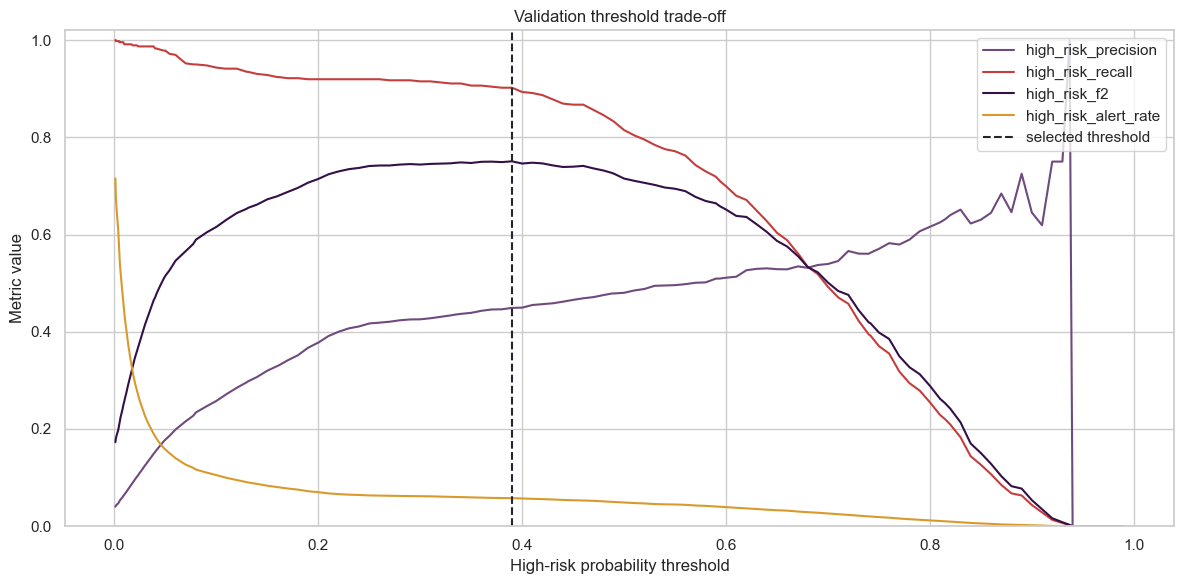

In [19]:
threshold_plot_data = high_risk_threshold_tuning.sort_values("threshold")
fig, ax = plt.subplots(figsize=(12, 6))
for metric, color in [
    ("high_risk_precision", "#6F4A7C"),
    ("high_risk_recall", "#C53D3D"),
    ("high_risk_f2", "#331045"),
    ("high_risk_alert_rate", "#D99A2B")]:
    ax.plot(threshold_plot_data["threshold"], threshold_plot_data[metric], label=metric, color=color)
ax.axvline(best_high_risk_threshold, color="#26232A", linestyle="--", label="selected threshold")
ax.set_title("Validation threshold trade-off")
ax.set_xlabel("High-risk probability threshold")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
selected_validation_tuned_prediction = predict_with_high_risk_threshold(
    selected_validation_probability,
    best_high_risk_threshold)
selected_validation_tuned_output = evaluate_predictions(
    selected_candidate_name,
    "valid",
    "high_risk_threshold",
    best_high_risk_threshold,
    y_valid,
    selected_validation_tuned_prediction,
    selected_validation_probability)

validation_rule_comparison = pd.DataFrame(
    [
        selected_validation_default_output[0],
        selected_validation_tuned_output[0]])
display(
    validation_rule_comparison[
        [
            "decision_rule",
            "threshold",
            "macro_f1",
            "high_risk_precision",
            "high_risk_recall",
            "high_risk_f2",
            "high_risk_alert_rate",
            "false_alarm_rate"]].round(4))

,decision_rule,threshold,macro_f1,high_risk_precision,high_risk_recall,high_risk_f2,high_risk_alert_rate,false_alarm_rate
0,default_argmax,NaN,0.6535,0.4426,0.9063,0.7493,0.0588,0.0337
1,high_risk_threshold,0.3900,0.6552,0.4490,0.9020,0.7505,0.0576,0.0327


## 10. Final test-period evaluation


The model configuration and threshold are now frozen. We evaluate both the default and tuned decision rules on the test period for transparency.


In [21]:
test_probability = align_probabilities(
    selected_model.predict_proba(X_test),
    selected_model.classes_)
test_default_prediction = selected_model.predict(X_test).astype(int)
test_tuned_prediction = predict_with_high_risk_threshold(
    test_probability,
    best_high_risk_threshold)

test_default_output = evaluate_predictions(
    selected_candidate_name,
    "test",
    "default_argmax",
    None,
    y_test,
    test_default_prediction,
    test_probability)
test_tuned_output = evaluate_predictions(
    selected_candidate_name,
    "test",
    "high_risk_threshold",
    best_high_risk_threshold,
    y_test,
    test_tuned_prediction,
    test_probability)

stronger_model_results = pd.DataFrame(
    [
        selected_validation_default_output[0],
        test_default_output[0],
        selected_validation_tuned_output[0],
        test_tuned_output[0]])
display(
    stronger_model_results[
        [
            "split",
            "decision_rule",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "high_risk_precision",
            "high_risk_recall",
            "high_risk_f2",
            "alert_rate",
            "false_alarm_rate",
            "high_risk_pr_auc"]].round(4))

,split,decision_rule,threshold,accuracy,balanced_accuracy,macro_f1,high_risk_precision,high_risk_recall,high_risk_f2,alert_rate,false_alarm_rate,high_risk_pr_auc
0,valid,default_argmax,NaN,0.7023,0.7670,0.6535,0.4426,0.9063,0.7493,0.4516,0.0337,0.5373
1,test,default_argmax,NaN,0.6982,0.7376,0.6368,0.4205,0.8196,0.6888,0.4471,0.0332,0.5032
2,valid,high_risk_threshold,0.3900,0.7028,0.7659,0.6552,0.4490,0.9020,0.7505,0.4508,0.0327,0.5373
3,test,high_risk_threshold,0.3900,0.6990,0.7360,0.6394,0.4308,0.8126,0.6903,0.4465,0.0316,0.5032


In [22]:
print("Test confusion matrix — tuned threshold")
display(test_tuned_output[2])

print("Test classification report — tuned threshold")
display(test_tuned_output[1].round(4))

Test confusion matrix — tuned threshold


,pred_Low Risk,pred_Medium Risk,pred_High Risk
actual_Low Risk,9568,3867,373
actual_Medium Risk,1433,3948,240
actual_High Risk,69,38,464


Test classification report — tuned threshold


,label,label_name,precision,recall,f1_score,support
0,0,Low Risk,0.8643,0.6929,0.7692,13808
1,1,Medium Risk,0.5027,0.7024,0.5860,5621
2,2,High Risk,0.4308,0.8126,0.5631,571


### Quantify uncertainty for the rare high-risk class

Point estimates can look more stable than they really are when only a few high-risk rows exist. Wilson intervals provide an interpretable 95% range for high-risk precision and recall without assuming a large sample.


In [23]:
def wilson_interval(successes, trials, z_value=1.96):
    if trials == 0:
        return np.nan, np.nan
    proportion = successes / trials
    denominator = 1 + z_value**2 / trials
    centre = (proportion + z_value**2 / (2 * trials)) / denominator
    margin = (
        z_value
        * np.sqrt(
            proportion * (1 - proportion) / trials
            + z_value**2 / (4 * trials**2))
        / denominator)
    return max(0.0, centre - margin), min(1.0, centre + margin)


confidence_interval_rows = []
for split_name, summary in [
    ("validation", selected_validation_tuned_output[0]),
    ("test", test_tuned_output[0]),
]:
    tp = int(summary["high_risk_tp"])
    fp = int(summary["high_risk_fp"])
    fn = int(summary["high_risk_fn"])
    for metric, successes, trials in [
        ("high_risk_precision", tp, tp + fp),
        ("high_risk_recall", tp, tp + fn)]:
        lower, upper = wilson_interval(successes, trials)
        confidence_interval_rows.append(
            {
                "split": split_name,
                "metric": metric,
                "estimate": successes / trials if trials else np.nan,
                "successes": successes,
                "trials": trials,
                "lower_95_pct": lower,
                "upper_95_pct": upper})

random_forest_high_risk_confidence_intervals = pd.DataFrame(confidence_interval_rows)
display(random_forest_high_risk_confidence_intervals.round(4))


,split,metric,estimate,successes,trials,lower_95_pct,upper_95_pct
0,validation,high_risk_precision,0.4490,414,922,0.4172,0.4813
1,validation,high_risk_recall,0.9020,414,459,0.8713,0.9259
2,test,high_risk_precision,0.4308,464,1077,0.4015,0.4606
3,test,high_risk_recall,0.8126,464,571,0.7786,0.8425


## 11. Compare against the earlier baselines


In [24]:
baseline_results_path = BASELINE_DIR / "baseline_model_results.csv"
baseline_results = (
    pd.read_csv(baseline_results_path)
    if baseline_results_path.exists()
    else None)

if baseline_results is not None:
    comparison_columns = [
        "model",
        "split",
        "decision_rule",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "high_risk_precision",
        "high_risk_recall",
        "high_risk_f2",
        "alert_rate",
        "false_alarm_rate",
        "high_risk_pr_auc"]
    baseline_comparison = baseline_results.copy()
    baseline_comparison["decision_rule"] = "default_argmax"
    for column in comparison_columns:
        if column not in baseline_comparison.columns:
            baseline_comparison[column] = np.nan

    random_forest_comparison = stronger_model_results.copy()
    model_comparison_with_baseline = pd.concat(
        [
            baseline_comparison[comparison_columns],
            random_forest_comparison[comparison_columns]],
        ignore_index=True)
    display(
        model_comparison_with_baseline.loc[
            model_comparison_with_baseline["split"] == "test"].round(4))
else:
    model_comparison_with_baseline = stronger_model_results.copy()
    print("Baseline results were not found; the Random Forest evaluation remains complete.")


,model,split,decision_rule,accuracy,balanced_accuracy,macro_f1,high_risk_precision,high_risk_recall,high_risk_f2,alert_rate,false_alarm_rate,high_risk_pr_auc
3,majority_class,test,default_argmax,0.6904,0.3333,0.2723,0.0000,0.0000,0.0000,0.0000,0.0000,0.0286
4,gaussian_naive_bayes,test,default_argmax,0.5628,0.6339,0.4701,0.1699,0.7618,0.4489,0.5562,0.1094,0.1854
5,class_weighted_logistic_regression,test,default_argmax,0.6487,0.7095,0.5795,0.3255,0.8039,0.6213,0.5064,0.0489,0.4750
7,balanced_medium,test,default_argmax,0.6982,0.7376,0.6368,0.4205,0.8196,0.6888,0.4471,0.0332,0.5032
9,balanced_medium,test,high_risk_threshold,0.6990,0.7360,0.6394,0.4308,0.8126,0.6903,0.4465,0.0316,0.5032


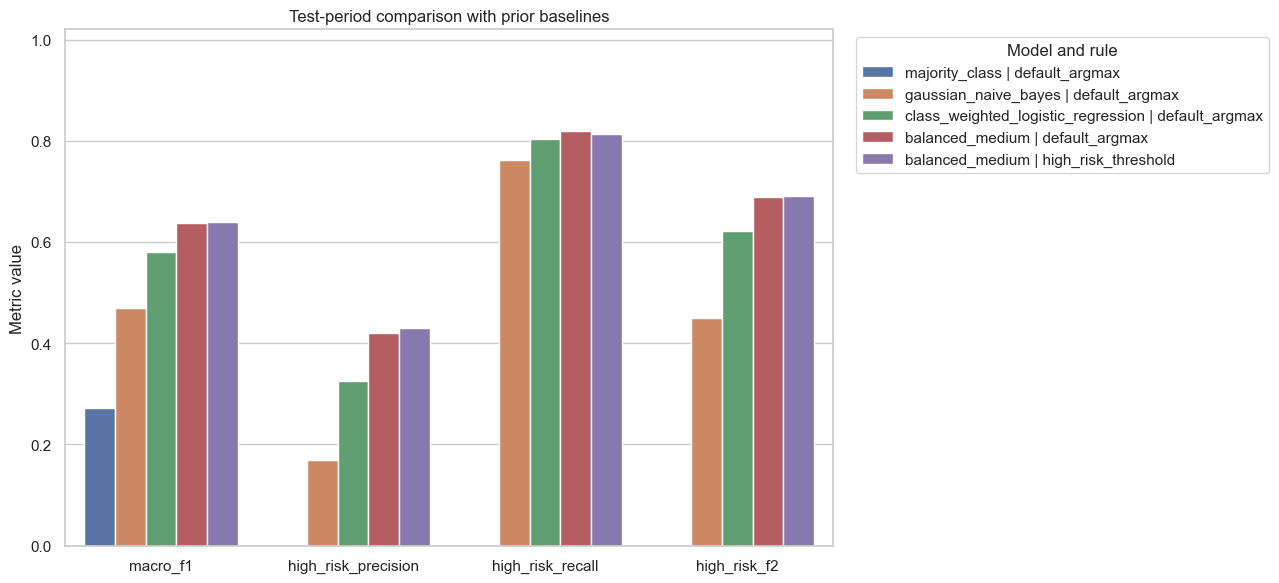

In [25]:
test_comparison_plot = model_comparison_with_baseline.loc[
    model_comparison_with_baseline["split"] == "test"
].copy()
if len(test_comparison_plot) > 1:
    test_comparison_plot["model_rule"] = (
        test_comparison_plot["model"].astype(str)
        + " | "
        + test_comparison_plot["decision_rule"].astype(str))
    metrics = ["macro_f1", "high_risk_precision", "high_risk_recall", "high_risk_f2"]
    plot_data = test_comparison_plot.melt(
        id_vars="model_rule",
        value_vars=metrics,
        var_name="metric",
        value_name="value")
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.barplot(data=plot_data, x="metric", y="value", hue="model_rule", ax=ax)
    ax.set_title("Test-period comparison with prior baselines")
    ax.set_xlabel("")
    ax.set_ylabel("Metric value")
    ax.set_ylim(0, 1.02)
    ax.legend(title="Model and rule", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## 12. Inspect feature importance and tree complexity


In [26]:
random_forest_feature_importance = (
    pd.DataFrame(
        {
            "feature": X_train.columns,
            "importance": selected_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True))
random_forest_feature_importance.insert(
    0,
    "rank",
    np.arange(1, len(random_forest_feature_importance) + 1))
random_forest_feature_importance["cumulative_importance"] = (
    random_forest_feature_importance["importance"].cumsum())
display(random_forest_feature_importance.head(20).round(5))


,rank,feature,importance,cumulative_importance
0,1,customers_lag_1m,0.0383,0.0383
1,2,trend_slope_3m,0.0333,0.0716
2,3,unit_share_lag_1m,0.0330,0.1046
3,4,units_lag_1m,0.0322,0.1368
4,5,revenue_lag_1m,0.0321,0.1689
5,6,customer_share_category_region,0.0315,0.2004
6,7,volatility_3m,0.0299,0.2303
7,8,revenue_volatility_3m,0.0287,0.2590
8,9,revenue,0.0252,0.2843
9,10,units_sold,0.0245,0.3088


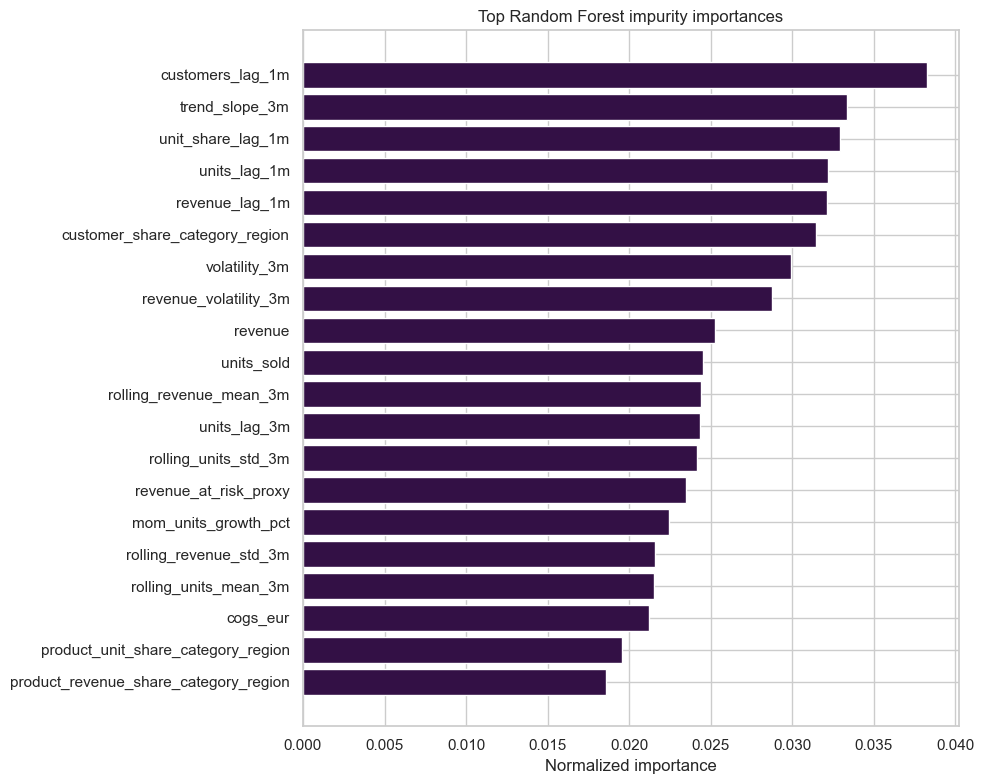

In [27]:
top_importance_plot = random_forest_feature_importance.head(20).sort_values("importance")
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_importance_plot["feature"], top_importance_plot["importance"], color="#331045")
ax.set_title("Top Random Forest impurity importances")
ax.set_xlabel("Normalized importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [28]:
def validation_permutation_importance(
    model,
    X,
    y,
    threshold,
    features,
    repeats=3,
    random_seed=RANDOM_SEED):
    rng = np.random.default_rng(random_seed)
    base_probability = align_probabilities(model.predict_proba(X), model.classes_)
    base_prediction = predict_with_high_risk_threshold(base_probability, threshold)
    base_macro_f1 = f1_score(y, base_prediction, average="macro", zero_division=0)

    working = X.copy()
    rows = []
    for feature in features:
        original_values = working[feature].to_numpy(copy=True)
        drops = []
        for _ in range(repeats):
            working[feature] = rng.permutation(original_values)
            probability = align_probabilities(model.predict_proba(working), model.classes_)
            prediction = predict_with_high_risk_threshold(probability, threshold)
            permuted_macro_f1 = f1_score(y, prediction, average="macro", zero_division=0)
            drops.append(base_macro_f1 - permuted_macro_f1)
        working[feature] = original_values
        rows.append(
            {
                "feature": feature,
                "baseline_validation_macro_f1": base_macro_f1,
                "mean_macro_f1_drop": float(np.mean(drops)),
                "std_macro_f1_drop": float(np.std(drops)),
                "repeats": repeats})
    return pd.DataFrame(rows).sort_values("mean_macro_f1_drop", ascending=False).reset_index(drop=True)


permutation_features = random_forest_feature_importance.head(15)["feature"].tolist()
random_forest_permutation_importance_valid = validation_permutation_importance(
    selected_model,
    X_valid,
    y_valid,
    best_high_risk_threshold,
    permutation_features,
    repeats=3)
display(random_forest_permutation_importance_valid.round(5))


,feature,baseline_validation_macro_f1,mean_macro_f1_drop,std_macro_f1_drop,repeats
0,units_lag_3m,0.6552,0.0174,0.0015,3
1,trend_slope_3m,0.6552,0.0153,0.0016,3
2,revenue_volatility_3m,0.6552,0.0054,0.0009,3
3,volatility_3m,0.6552,0.0053,0.0013,3
4,customer_share_category_region,0.6552,0.0028,0.0015,3
5,units_sold,0.6552,-0.0004,0.0006,3
6,unit_share_lag_1m,0.6552,-0.0005,0.0008,3
7,units_lag_1m,0.6552,-0.0005,0.0002,3
8,revenue,0.6552,-0.0009,0.0008,3
9,revenue_at_risk_proxy,0.6552,-0.0017,0.0008,3


In [29]:
tree_complexity = pd.DataFrame(
    {
        "tree_number": np.arange(1, len(selected_model.estimators_) + 1),
        "depth": [tree.tree_.max_depth for tree in selected_model.estimators_],
        "leaf_count": [tree.tree_.n_leaves for tree in selected_model.estimators_],
        "node_count": [tree.tree_.node_count for tree in selected_model.estimators_]})
display(tree_complexity.describe().round(2))


,tree_number,depth,leaf_count,node_count
count,220.0000,220.0000,220.0000,220.0000
mean,110.5000,14.0000,"1,718.4400","3,435.8700"
std,63.6500,0.0000,152.6600,305.3200
min,1.0000,14.0000,"1,355.0000","2,709.0000"
25%,55.7500,14.0000,"1,610.7500","3,220.5000"
50%,110.5000,14.0000,"1,710.5000","3,420.0000"
75%,165.2500,14.0000,"1,815.2500","3,629.5000"
max,220.0000,14.0000,"2,090.0000","4,179.0000"


## 13. Create row-level validation and test predictions


In [30]:
def prediction_table(X, y, identifiers, probability, default_prediction, tuned_prediction):
    if identifiers is not None:
        result = identifiers.drop(columns=[TARGET_COL], errors="ignore").reset_index(drop=True).copy()
    else:
        result = pd.DataFrame({"row_number": np.arange(len(X), dtype=int)})

    result["actual_label"] = np.asarray(y, dtype=int)
    result["actual_label_name"] = result["actual_label"].map(LABEL_NAMES)
    result["predicted_label_default"] = default_prediction.astype(int)
    result["predicted_label_tuned"] = tuned_prediction.astype(int)
    result["predicted_label_tuned_name"] = pd.Series(tuned_prediction).map(LABEL_NAMES).to_numpy()
    result["proba_low"] = probability[:, 0]
    result["proba_medium"] = probability[:, 1]
    result["proba_high"] = probability[:, 2]
    result["high_risk_threshold"] = best_high_risk_threshold
    result["predicted_risk_score_0_10"] = probability @ np.array([0.0, 5.0, 10.0])
    result["alert_flag"] = (tuned_prediction > 0).astype(int)
    result["high_risk_alert_flag"] = (tuned_prediction == 2).astype(int)
    return result

valid_prediction_probabilities = prediction_table(
    X_valid,
    y_valid,
    identifier_tables["valid"],
    selected_validation_probability,
    selected_validation_default_prediction,
    selected_validation_tuned_prediction)
test_prediction_probabilities = prediction_table(
    X_test,
    y_test,
    identifier_tables["test"],
    test_probability,
    test_default_prediction,
    test_tuned_prediction)

# Backward-compatible aliases from the original file.
valid_prediction_probabilities["valid_actual"] = valid_prediction_probabilities["actual_label"]
valid_prediction_probabilities["valid_pred_default"] = valid_prediction_probabilities["predicted_label_default"]
valid_prediction_probabilities["valid_pred_tuned"] = valid_prediction_probabilities["predicted_label_tuned"]

display(valid_prediction_probabilities.head(8))


,product_id,year_month,region_id,region,target_month,actual_label,actual_label_name,predicted_label_default,predicted_label_tuned,predicted_label_tuned_name,proba_low,proba_medium,proba_high,high_risk_threshold,predicted_risk_score_0_10,alert_flag,high_risk_alert_flag,valid_actual,valid_pred_default,valid_pred_tuned
0,1000,2024-06,1,Western EU,2024-07,0,Low Risk,1,1,Medium Risk,0.3363,0.6461,0.0175,0.3900,3.4060,1,0,0,1,1
1,1000,2024-07,1,Western EU,2024-08,0,Low Risk,1,1,Medium Risk,0.2271,0.7646,0.0083,0.3900,3.9062,1,0,0,1,1
2,1000,2024-08,1,Western EU,2024-09,0,Low Risk,0,0,Low Risk,0.5266,0.4449,0.0285,0.3900,2.5094,0,0,0,0,0
3,1000,2024-09,1,Western EU,2024-10,0,Low Risk,0,0,Low Risk,0.5369,0.4289,0.0341,0.3900,2.4859,0,0,0,0,0
4,1000,2024-10,1,Western EU,2024-11,0,Low Risk,0,0,Low Risk,0.5788,0.3407,0.0805,0.3900,2.5082,0,0,0,0,0
5,1000,2024-11,1,Western EU,2024-12,1,Medium Risk,1,1,Medium Risk,0.4045,0.5681,0.0275,0.3900,3.1151,1,0,1,1,1
6,1000,2024-12,1,Western EU,2025-01,1,Medium Risk,0,0,Low Risk,0.5710,0.3842,0.0448,0.3900,2.3692,0,0,1,0,0
7,1000,2025-01,1,Western EU,2025-02,0,Low Risk,0,0,Low Risk,0.7991,0.1754,0.0255,0.3900,1.1320,0,0,0,0,0


## 14. Refit on labeled history and score the latest month


In [31]:
final_random_forest_model = None
random_forest_scoring_predictions = None

if X_scoring is not None:
    X_all_labeled = pd.concat([X_train, X_valid, X_test], ignore_index=True)
    y_all_labeled = pd.concat([y_train, y_valid, y_test], ignore_index=True)

    final_random_forest_model = clone(selected_model)
    final_random_forest_model.fit(X_all_labeled, y_all_labeled)

    scoring_probability = align_probabilities(
        final_random_forest_model.predict_proba(X_scoring),
        final_random_forest_model.classes_)
    scoring_prediction = predict_with_high_risk_threshold(
        scoring_probability,
        best_high_risk_threshold)

    if identifier_tables["scoring"] is not None:
        random_forest_scoring_predictions = identifier_tables["scoring"].copy().reset_index(drop=True)
    else:
        random_forest_scoring_predictions = pd.DataFrame(
            {"row_number": np.arange(len(X_scoring), dtype=int)})

    random_forest_scoring_predictions["model_name"] = selected_candidate_name
    random_forest_scoring_predictions["high_risk_threshold"] = best_high_risk_threshold
    random_forest_scoring_predictions["predicted_risk_label"] = scoring_prediction.astype(int)
    random_forest_scoring_predictions["predicted_risk_label_name"] = pd.Series(scoring_prediction).map(LABEL_NAMES).to_numpy()
    random_forest_scoring_predictions["probability_low_risk"] = scoring_probability[:, 0]
    random_forest_scoring_predictions["probability_medium_risk"] = scoring_probability[:, 1]
    random_forest_scoring_predictions["probability_high_risk"] = scoring_probability[:, 2]
    random_forest_scoring_predictions["predicted_risk_score_0_10"] = scoring_probability @ np.array([0.0, 5.0, 10.0])
    random_forest_scoring_predictions["alert_flag"] = (scoring_prediction > 0).astype(int)
    random_forest_scoring_predictions["high_risk_alert_flag"] = (scoring_prediction == 2).astype(int)

    display(random_forest_scoring_predictions.head(10))
    display(
        random_forest_scoring_predictions["predicted_risk_label_name"]
        .value_counts(dropna=False)
        .rename("rows")
        .to_frame())
else:
    print("No scoring matrix was found. Labeled model evaluation is still complete.")


,product_id,year_month,region_id,region,target_month,model_name,high_risk_threshold,predicted_risk_label,predicted_risk_label_name,probability_low_risk,probability_medium_risk,probability_high_risk,predicted_risk_score_0_10,alert_flag,high_risk_alert_flag
0,1000,2025-12,1,Western EU,2026-01,balanced_medium,0.3900,0,Low Risk,0.6108,0.1931,0.1961,2.9261,0,0
1,1000,2025-12,10,Northern EU,2026-01,balanced_medium,0.3900,1,Medium Risk,0.4318,0.5386,0.0296,2.9886,1,0
2,1000,2025-12,2,Western EU,2026-01,balanced_medium,0.3900,0,Low Risk,0.7102,0.2763,0.0135,1.5165,0,0
3,1000,2025-12,3,Southern EU,2026-01,balanced_medium,0.3900,1,Medium Risk,0.3576,0.6326,0.0098,3.2608,1,0
4,1000,2025-12,4,Southern EU,2026-01,balanced_medium,0.3900,0,Low Risk,0.7403,0.2396,0.0201,1.3990,0,0
5,1000,2025-12,5,Northern EU,2026-01,balanced_medium,0.3900,1,Medium Risk,0.4285,0.5570,0.0145,2.9297,1,0
6,1000,2025-12,6,Northern EU,2026-01,balanced_medium,0.3900,1,Medium Risk,0.3488,0.6465,0.0047,3.2791,1,0
7,1000,2025-12,7,Eastern EU,2026-01,balanced_medium,0.3900,0,Low Risk,0.7982,0.2018,0.0000,1.0089,0,0
8,1000,2025-12,8,Eastern EU,2026-01,balanced_medium,0.3900,1,Medium Risk,0.2741,0.7241,0.0018,3.6383,1,0
9,1000,2025-12,9,Western EU,2026-01,balanced_medium,0.3900,0,Low Risk,0.6377,0.3446,0.0177,1.8999,0,0


,rows
predicted_risk_label_name,
Low Risk,985
Medium Risk,938
High Risk,77


## 15. Recommendations and limitations


In [32]:
def make_recommendations(validation_default, validation_tuned, training_target, importance):
    recommendations = []
    high_share = float((training_target == 2).mean())

    if validation_tuned["high_risk_recall"] > validation_default["high_risk_recall"]:
        threshold_message = "The tuned threshold improves high-risk recall and should be retained as a configurable business rule."
    else:
        threshold_message = "The default decision rule is already competitive; retain threshold tuning as a monitored operational control."
    recommendations.append(
        {"priority": "Medium", "area": "Threshold strategy", "recommendation": threshold_message})

    if validation_tuned["false_alarm_rate"] > 0.05:
        false_alarm_message = "False alarms exceed 5%. Increase the threshold or introduce a ranked review queue with a fixed alert capacity."
    else:
        false_alarm_message = "Validation false alarms are controlled, but the rate should be monitored monthly as the data distribution changes."
    recommendations.append(
        {"priority": "High", "area": "False alarms", "recommendation": false_alarm_message})

    if validation_tuned["high_risk_recall"] < MINIMUM_HIGH_RISK_RECALL:
        recall_message = "High-risk recall remains below the target. Add leading indicators and compare gradient-boosted trees using the same temporal design."
    else:
        recall_message = "High-risk recall reaches the initial target. Next optimize probability calibration and business alert capacity."
    recommendations.append(
        {"priority": "High", "area": "High-risk recall", "recommendation": recall_message})

    if high_share < 0.005:
        recommendations.append(
            {
                "priority": "High",
                "area": "Rare-event stability",
                "recommendation": (
                    "Very few high-risk rows are available. Add walk-forward monthly evaluation, "
                    "confidence intervals, and more history before interpreting small metric changes.")})

    if importance.head(5)["importance"].sum() > 0.80:
        recommendations.append(
            {
                "priority": "High",
                "area": "Feature concentration",
                "recommendation": (
                    "Most model importance is concentrated in a few features. Reconfirm their timing, "
                    "business definition, and stability to rule out proxy leakage.")})

    recommendations.extend(
        [
            {
                "priority": "Medium",
                "area": "Probability calibration",
                "recommendation": "Calibrate probabilities with time-aware validation before treating them as literal risk likelihoods."},
            {
                "priority": "Medium",
                "area": "Production monitoring",
                "recommendation": "Monitor recall, precision, alert rate, probability drift, and feature drift by target month, region, and product category."}])
    return pd.DataFrame(recommendations)


stronger_model_recommendations = make_recommendations(
    selected_validation_default_output[0],
    selected_validation_tuned_output[0],
    y_train,
    random_forest_feature_importance)
display(stronger_model_recommendations)


,priority,area,recommendation
0,Medium,Threshold strategy,The default decision rule is already competiti...
1,High,False alarms,"Validation false alarms are controlled, but th..."
2,High,High-risk recall,High-risk recall reaches the initial target. N...
3,Medium,Probability calibration,Calibrate probabilities with time-aware valida...
4,Medium,Production monitoring,"Monitor recall, precision, alert rate, probabi..."


## 16. Export

Every original output filename is preserved. New files add candidate diagnostics, test and scoring predictions, permutation importance, model binaries, configuration metadata, and quality reporting.


In [33]:
stronger_model_results.to_csv(OUTPUT_DIR / "stronger_model_results.csv", index=False)
high_risk_threshold_tuning.to_csv(
    OUTPUT_DIR / "high_risk_threshold_tuning_valid.csv", index=False)
random_forest_feature_importance.to_csv(
    OUTPUT_DIR / "random_forest_feature_importance.csv", index=False)
stronger_model_recommendations.to_csv(
    OUTPUT_DIR / "stronger_model_recommendations.csv", index=False)

# Preserve the four original confusion-matrix and classification-report files.
evaluation_exports = {
    "valid_default": selected_validation_default_output,
    "test_default": test_default_output,
    "valid_tuned": selected_validation_tuned_output,
    "test_tuned": test_tuned_output}
for stem, output in evaluation_exports.items():
    _, class_report, matrix = output
    matrix.to_csv(OUTPUT_DIR / f"{stem}_confusion_matrix.csv")
    class_report.to_csv(OUTPUT_DIR / f"{stem}_classification_report.csv", index=False)

valid_prediction_probabilities.to_csv(
    OUTPUT_DIR / "valid_prediction_probabilities.csv", index=False)
test_prediction_probabilities.to_csv(
    OUTPUT_DIR / "test_prediction_probabilities.csv", index=False)
candidate_validation_results.to_csv(
    OUTPUT_DIR / "random_forest_validation_candidate_results.csv", index=False)
candidate_training_diagnostics.to_csv(
    OUTPUT_DIR / "random_forest_candidate_training_diagnostics.csv", index=False)
random_forest_permutation_importance_valid.to_csv(
    OUTPUT_DIR / "random_forest_permutation_importance_valid.csv", index=False)
random_forest_high_risk_confidence_intervals.to_csv(
    OUTPUT_DIR / "random_forest_high_risk_confidence_intervals.csv", index=False)
tree_complexity.to_csv(
    OUTPUT_DIR / "random_forest_tree_complexity.csv", index=False)
model_comparison_with_baseline.to_csv(
    OUTPUT_DIR / "model_comparison_with_baseline.csv", index=False)
pd.DataFrame({"feature": X_train.columns, "feature_position": np.arange(X_train.shape[1])}).to_csv(
    OUTPUT_DIR / "random_forest_input_feature_list.csv", index=False)

if random_forest_scoring_predictions is not None:
    random_forest_scoring_predictions.to_csv(
        OUTPUT_DIR / "random_forest_scoring_predictions.csv", index=False)

joblib.dump(selected_model, OUTPUT_DIR / "selected_random_forest_train_model.joblib")
if final_random_forest_model is not None:
    joblib.dump(final_random_forest_model, OUTPUT_DIR / "selected_random_forest_refit_model.joblib")


In [34]:
model_configuration = {
    "selected_candidate": selected_candidate_name,
    "selected_parameters": selected_candidate_spec,
    "selection_metrics": ["high_risk_pr_auc", "high_risk_f2", "macro_f1", "log_loss"],
    "selected_high_risk_threshold": best_high_risk_threshold,
    "minimum_validation_high_risk_recall": MINIMUM_HIGH_RISK_RECALL,
    "threshold_selection_note": threshold_selection_note,
    "feature_count": X_train.shape[1],
    "random_seed": RANDOM_SEED,
    "model_library": "scikit-learn RandomForestClassifier"}
with open(OUTPUT_DIR / "random_forest_model_config.json", "w", encoding="utf-8") as file:
    json.dump(model_configuration, file, indent=2, default=str)


## 17. Final quality checks


In [35]:
original_required_outputs = [
    "stronger_model_results.csv",
    "high_risk_threshold_tuning_valid.csv",
    "random_forest_feature_importance.csv",
    "stronger_model_recommendations.csv",
    "valid_default_confusion_matrix.csv",
    "test_default_confusion_matrix.csv",
    "valid_tuned_confusion_matrix.csv",
    "test_tuned_confusion_matrix.csv",
    "valid_default_classification_report.csv",
    "test_default_classification_report.csv",
    "valid_tuned_classification_report.csv",
    "test_tuned_classification_report.csv",
    "valid_prediction_probabilities.csv"]
required_legacy_result_columns = {
    "model",
    "split",
    "decision_rule",
    "threshold",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "high_risk_recall",
    "high_risk_precision",
    "false_alarm_rate",
    "high_risk_alert_rate",
    "high_risk_tp",
    "high_risk_fp",
    "high_risk_fn",
    "high_risk_tn"}
required_legacy_probability_columns = {
    "valid_actual",
    "valid_pred_default",
    "valid_pred_tuned",
    "proba_low",
    "proba_medium",
    "proba_high"}

final_checks = {
    "feature_columns_match_across_splits": all(feature_alignment.values()),
    "target_is_not_a_feature": TARGET_COL not in X_train.columns,
    "identifiers_are_not_features": not any(column.endswith("_id") for column in X_train.columns),
    "feature_matrices_have_no_missing_values": feature_quality["missing_feature_values"].eq(0).all(),
    "feature_matrices_have_no_infinite_values": feature_quality["infinite_feature_values"].eq(0).all(),
    "all_training_rows_used": selected_model.n_features_in_ == X_train.shape[1],
    "all_target_classes_exist_in_training": set(RISK_LABELS).issubset(set(y_train.unique())),
    "selected_candidate_was_evaluated_on_validation": selected_candidate_name in candidate_validation_results["model"].tolist(),
    "selected_threshold_came_from_validation_grid": np.isclose(high_risk_threshold_tuning["threshold"], best_high_risk_threshold).any(),
    "validation_probabilities_sum_to_one": np.allclose(selected_validation_probability.sum(axis=1), 1.0),
    "test_probabilities_sum_to_one": np.allclose(test_probability.sum(axis=1), 1.0),
    "validation_prediction_rows_match": len(valid_prediction_probabilities) == len(X_valid),
    "test_prediction_rows_match": len(test_prediction_probabilities) == len(X_test),
    "scoring_prediction_rows_match": random_forest_scoring_predictions is None or len(random_forest_scoring_predictions) == len(X_scoring),
    "feature_importance_sums_to_one": np.isclose(random_forest_feature_importance["importance"].sum(), 1.0),
    "legacy_result_columns_preserved": required_legacy_result_columns.issubset(stronger_model_results.columns),
    "legacy_probability_columns_preserved": required_legacy_probability_columns.issubset(valid_prediction_probabilities.columns),
    "original_output_files_preserved": all((OUTPUT_DIR / name).exists() for name in original_required_outputs)}
if not chronology_summary.empty:
    final_checks["chronological_split_order"] = train_end < valid_start <= valid_end < test_start

quality_check_table = pd.DataFrame(
    {"check": list(final_checks.keys()), "passed": list(final_checks.values())})
display(quality_check_table)

failed_checks = quality_check_table.loc[~quality_check_table["passed"], "check"].tolist()
if failed_checks:
    raise AssertionError("Failed final checks: " + ", ".join(failed_checks))
print("All final Random Forest checks passed.")


,check,passed
0,feature_columns_match_across_splits,True
1,target_is_not_a_feature,True
2,identifiers_are_not_features,True
3,feature_matrices_have_no_missing_values,True
4,feature_matrices_have_no_infinite_values,True
5,all_training_rows_used,True
6,all_target_classes_exist_in_training,True
7,selected_candidate_was_evaluated_on_validation,True
8,selected_threshold_came_from_validation_grid,True
9,validation_probabilities_sum_to_one,True


All final Random Forest checks passed.


In [36]:
stronger_model_report = {
    "model": "scikit-learn RandomForestClassifier",
    "selected_candidate": selected_candidate_name,
    "best_high_risk_threshold": best_high_risk_threshold,
    "summary": stronger_model_results.to_dict(orient="records"),
    "candidate_validation_results": candidate_validation_results.to_dict(orient="records"),
    "candidate_training_diagnostics": candidate_training_diagnostics.to_dict(orient="records"),
    "top_20_features": random_forest_feature_importance.head(20).to_dict(orient="records"),
    "top_validation_permutation_features": random_forest_permutation_importance_valid.to_dict(orient="records"),
    "high_risk_confidence_intervals": random_forest_high_risk_confidence_intervals.to_dict(orient="records"),
    "recommendations": stronger_model_recommendations.to_dict(orient="records"),
    "final_checks": final_checks}
with open(OUTPUT_DIR / "stronger_model_report.json", "w", encoding="utf-8") as file:
    json.dump(stronger_model_report, file, indent=2, default=str)

with open(OUTPUT_DIR / "random_forest_quality_report.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "feature_quality": feature_quality.to_dict(orient="records"),
            "feature_alignment": feature_alignment,
            "chronology": chronology_summary.to_dict(orient="records"),
            "target_distribution": target_distribution_all.to_dict(orient="records"),
            "final_checks": final_checks},
        file,
        indent=2,
        default=str)

In [37]:
export_summary = pd.DataFrame(
    [
        {"file": path.name, "size_bytes": path.stat().st_size}
        for path in sorted(OUTPUT_DIR.iterdir())
        if path.is_file()])
display(export_summary)

print("\nRandom Forest workflow complete")
print("-" * 80)
print(f"Train rows:               {len(X_train):,}")
print(f"Validation rows:          {len(X_valid):,}")
print(f"Test rows:                {len(X_test):,}")
print(f"Model input features:     {X_train.shape[1]:,}")
print(f"Selected configuration:   {selected_candidate_name}")
print(f"Selected high-risk cutoff:{best_high_risk_threshold:>10.4f}")
print(f"Scoring rows:             {0 if X_scoring is None else len(X_scoring):,}")
print(f"Output folder:            {OUTPUT_DIR.resolve()}")


,file,size_bytes
0,high_risk_threshold_tuning_valid.csv,54822
1,model_comparison_with_baseline.csv,1934
2,random_forest_candidate_training_diagnostics.csv,314
3,random_forest_feature_importance.csv,15501
4,random_forest_high_risk_confidence_intervals.csv,437
5,random_forest_input_feature_list.csv,6394
6,random_forest_model_config.json,664
7,random_forest_permutation_importance_valid.csv,1342
8,random_forest_quality_report.json,4239
9,random_forest_scoring_predictions.csv,299195



Random Forest workflow complete
--------------------------------------------------------------------------------
Train rows:               63,280
Validation rows:          16,000
Test rows:                20,000
Model input features:     228
Selected configuration:   balanced_medium
Selected high-risk cutoff:    0.3900
Scoring rows:             2,000
Output folder:            C:\Benutzer\Anastasia\Lokale Daten\AS Portfolio\early-warning\data\full_data\ml_stronger
